# Rootzone LSTM V6 — Separate pH and EC Models, 10-Minute Walk-Forward

## Concept
Two independent LSTM models (pH and EC), each predicting every 10 minutes.

**Training:**
- **Endpoint-only loss**: MSE computed at t1 only. Gradients flow back through every step (true BPTT).
- **Recursive `prev`**: at each training step, `ph_prev`/`ec_prev` = model's own prediction from the previous step — identical to inference. No teacher forcing, no attribution shortcut.
- **Warmup**: 40 intervals → train initial model (100 epochs, shuffled each epoch).
- **Walk-forward**: for each eval interval — predict first (no weight update), then retrain on full growing set (20 epochs).

**Features**: causal only — each step sees from its timestamp back to t0 via rolling windows.
- pH: photosynthesis + acid chemistry chain
- EC: dilution + salt concentration chain

**Gap cap**: ≤12h intervals only (63 total).


In [1]:
# ==========================================
# 1. Imports + Data Loading
# ==========================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

ACID_FERTS = ["Phosphoric acid[mg]-H3PO4", "Ammonium Nitrate [mg] -NH4NO3"]
SALT_FERTS = ["Monopotassium Phosphate[mg] -KH2PO4", "Potassium Chloride[mg] - KCL",
              "Kortin [mg]", "Gypsum - CaSO4*2H2O [mg]"]

master_df = pd.read_csv("master.csv", parse_dates=["timestamp"])
master_df = master_df.sort_values("timestamp").set_index("timestamp")
for c in master_df.columns:
    master_df[c] = pd.to_numeric(master_df[c], errors="coerce")

labeled_idx = master_df.index[
    master_df["ph"].notna() & master_df["ec_ms"].notna()
].tolist()
print(f"Labeled points: {len(labeled_idx)}")

MAX_GAP_H  = 12.0
WARMUP_N   = 40

pairs = []
for i in range(1, len(labeled_idx)):
    t0 = labeled_idx[i-1]
    t1 = labeled_idx[i]
    gap_h = (t1 - t0).total_seconds() / 3600.0
    if 0.2 <= gap_h <= MAX_GAP_H:
        pairs.append((t0, t1, gap_h))

print(f"Intervals ≤{MAX_GAP_H}h: {len(pairs)}")
print(f"Warmup: {WARMUP_N}  |  Walk-forward eval: {len(pairs) - WARMUP_N}")


Device: cpu
Labeled points: 109
Intervals ≤12.0h: 63
Warmup: 40  |  Walk-forward eval: 23


In [2]:
# ==========================================
# 2. Environment Feature Matrix
# ==========================================
# Build all environment features once for the full timeline.
# Rolling windows are computed globally — they look backwards in real time,
# which is causal: step k only sees data from before its own timestamp.
# ph_prev / ec_prev are NOT here — injected per-step during sequence building.

def build_env(df):
    d = df.copy()
    def _n(c): return pd.to_numeric(d[c], errors="coerce").fillna(0.0)

    # Instantaneous
    d["ET0_inst"]    = _n("ET0")
    d["temp_inst"]   = _n("internal_air_temp_c")
    d["rad_inst"]    = _n("internal_radiation")
    d["rh_inst"]     = _n("internal_rh_%")
    d["irr_inst"]    = _n("irrigation_ml_current")
    d["canopy_inst"] = _n("canopy_cover")

    ess = 0.6108 * np.exp(17.27 * d["temp_inst"] / (d["temp_inst"] + 237.3))
    d["vpd_inst"] = ess * (1.0 - d["rh_inst"] / 100.0)

    d["acid_inst"] = sum(_n(c) for c in ACID_FERTS if c in d.columns)
    d["salt_inst"] = sum(_n(c) for c in SALT_FERTS if c in d.columns)
    d["fert_b_inst"] = _n("fertilization_type_b_flag")

    # Exponential acid decay  λ=0.34/hr
    alpha = np.exp(-0.34 * (10.0 / 60.0))
    acid_arr = d["acid_inst"].values.astype(float)
    decay = np.zeros(len(acid_arr))
    for k in range(1, len(acid_arr)):
        decay[k] = decay[k-1] * alpha + acid_arr[k]
    d["acid_decay_inst"] = decay

    # Rolling 6h (36 steps) — causal, looks backwards
    W6 = 36
    d["roll_ET0_6h"]  = d["ET0_inst"].rolling(W6, min_periods=1).sum()
    d["roll_rad_6h"]  = d["rad_inst"].rolling(W6, min_periods=1).mean()
    d["roll_temp_6h"] = d["temp_inst"].rolling(W6, min_periods=1).mean()
    d["roll_vpd_6h"]  = d["vpd_inst"].rolling(W6, min_periods=1).mean()
    d["roll_irr_6h"]  = d["irr_inst"].rolling(W6, min_periods=1).sum()

    # Rolling 1h (6 steps)
    d["roll_irr_1h"]  = d["irr_inst"].rolling(6, min_periods=1).sum()

    # Interaction features (causal — use rolling means, not window-ahead values)
    d["photo_temp_x"]     = d["vpd_inst"]   * d["temp_inst"]   # biochemical CO2 uptake
    d["rad_x_canopy"]     = d["rad_inst"]   * d["canopy_inst"] # light intercepted
    d["temp_x_canopy"]    = d["temp_inst"]  * d["canopy_inst"] # root respiration
    d["transpiration_x"]  = d["vpd_inst"]   * d["canopy_inst"] # transpiration pull
    d["evapo_conc_x"]     = d["ET0_inst"]   * d["canopy_inst"] # evaporative concentration

    # Time encoding
    hour = d.index.hour + d.index.minute / 60.0
    d["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
    d["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)

    return d

env_df = build_env(master_df)

# ── Per-model feature lists ───────────────────────────────────────────────────
# pH: photosynthesis + acid chemistry chain
# State features (ph_prev, gap_remaining_h) injected per-step — not listed here
PH_ENV_FEATURES = [
    "ET0_inst", "rad_inst", "temp_inst", "rh_inst", "vpd_inst",
    "canopy_inst",
    "acid_inst", "acid_decay_inst",
    "roll_ET0_6h", "roll_rad_6h", "roll_temp_6h", "roll_vpd_6h",
    "photo_temp_x", "rad_x_canopy", "temp_x_canopy",
    "hour_sin", "hour_cos",
]

# EC: dilution + salt concentration chain
EC_ENV_FEATURES = [
    "irr_inst", "ET0_inst", "vpd_inst", "canopy_inst",
    "salt_inst", "fert_b_inst",
    "roll_irr_6h", "roll_ET0_6h", "roll_irr_1h",
    "transpiration_x", "evapo_conc_x",
    "hour_sin", "hour_cos",
]

# Full step vectors: [target_prev, gap_remaining_h] + env features
N_PH = 2 + len(PH_ENV_FEATURES)   # ph_prev + gap_remaining_h + env
N_EC = 2 + len(EC_ENV_FEATURES)   # ec_prev + gap_remaining_h + env

print(f"pH feature vector size: {N_PH}  ({len(PH_ENV_FEATURES)} env + 2 state)")
print(f"EC feature vector size: {N_EC}  ({len(EC_ENV_FEATURES)} env + 2 state)")


pH feature vector size: 19  (17 env + 2 state)
EC feature vector size: 15  (13 env + 2 state)


In [3]:
# ==========================================
# 3. Model Architecture
# ==========================================

HIDDEN_SIZE    = 64
NUM_LAYERS     = 1
DROPOUT        = 0.3
LR             = 1e-3
INITIAL_EPOCHS = 100
FINETUNE_EPOCHS = 20
CHUNK_HOURS    = 6.0   # BPTT chunk size — hidden state reset between chunks in training

class RootzoneLSTM(nn.Module):
    """Single-target LSTM: predicts Δ(target) per 10-min step."""
    def __init__(self, n_features):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            batch_first=True,
        )
        self.drop = nn.Dropout(DROPOUT)
        self.head = nn.Linear(HIDDEN_SIZE, 1)

    def forward(self, x, hidden=None):
        # x: (1, T, n_features)
        out, hidden = self.lstm(x, hidden)
        out = self.drop(out)
        delta = self.head(out).squeeze(-1)   # (1, T)
        return delta, hidden


def make_model(n_features):
    m   = RootzoneLSTM(n_features).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=INITIAL_EPOCHS)
    return m, opt, sch


print(f"pH model params:  {sum(p.numel() for p in RootzoneLSTM(N_PH).parameters()):,}")
print(f"EC model params:  {sum(p.numel() for p in RootzoneLSTM(N_EC).parameters()):,}")


pH model params:  21,825
EC model params:  20,801


In [4]:
# ==========================================
# 4. Scaler
# ==========================================
# Fit mean/std once on warmup intervals.
# Uses attributed running prev (ground truth) just for scaler fitting —
# this is fine since the scaler only needs representative feature ranges.

def fit_scaler(pairs, env_df, master_df, env_features, target_col, is_ph=True):
    all_rows = []
    for t0, t1, gap_h in pairs:
        t0_val = float(master_df.loc[t0, target_col])
        t1_val = float(master_df.loc[t1, target_col])
        delta  = t1_val - t0_val

        seg = env_df.loc[(env_df.index > t0) & (env_df.index <= t1), env_features]
        if len(seg) == 0: continue
        K = len(seg)

        if is_ph:
            et0 = seg["ET0_inst"].values if "ET0_inst" in seg.columns else np.ones(K)
            s = et0.sum()
            w = et0 / s if s > 0 else np.ones(K) / K
        else:
            w = np.ones(K) / K

        delta_steps = delta * w
        run = t0_val
        env_vals = seg.values.astype(np.float32)
        for k in range(K):
            gap_rem = gap_h * (1.0 - k / K)
            row = np.concatenate([[run, gap_rem], env_vals[k]])
            all_rows.append(row.astype(np.float32))
            run += float(delta_steps[k])

    arr  = np.vstack(all_rows)
    mean = arr.mean(0).astype(np.float32)
    std  = (arr.std(0) + 1e-8).astype(np.float32)
    return mean, std

print("Scaler defined.")


Scaler defined.


In [5]:
# ==========================================
# 5. Training Function — True BPTT, Endpoint-Only Loss
# ==========================================
# run_interval_train():
#   - Unrolls the full interval step-by-step inside a live PyTorch graph
#   - At each step: prev = model's own prediction from step k-1 (recursive)
#   - Loss = MSE(pred_t1, true_t1) — endpoint only
#   - loss.backward() propagates through all K steps
#
# train_on_pairs():
#   - Runs all intervals in the pair list for `epochs` passes (shuffled)
#   - Used for both initial warmup training and walk-forward fine-tuning

def run_interval_train(t0, t1, gap_h, env_df, master_df,
                        env_features, target_col, model, scaler, optimizer,
                        is_ph=True):
    """One training pass through a single interval. Returns scalar loss."""
    t0_val  = float(master_df.loc[t0, target_col])
    t1_true = float(master_df.loc[t1, target_col])

    seg = env_df.loc[(env_df.index > t0) & (env_df.index <= t1), env_features]
    if len(seg) == 0: return None

    K        = len(seg)
    env_vals = seg.values.astype(np.float32)
    mean, std = scaler

    model.train()
    optimizer.zero_grad()

    run    = torch.tensor(t0_val, dtype=torch.float32, device=DEVICE)
    hidden = None

    for k in range(K):
        gap_rem = gap_h * (1.0 - k / K)
        env_t   = torch.tensor(env_vals[k], dtype=torch.float32, device=DEVICE)
        feat    = torch.cat([run.unsqueeze(0),
                             torch.tensor([gap_rem], device=DEVICE),
                             env_t])
        feat_n  = (feat - torch.tensor(mean, device=DEVICE)) / torch.tensor(std, device=DEVICE)
        x       = feat_n.unsqueeze(0).unsqueeze(0)   # (1,1,n_feat)
        delta, hidden = model(x, hidden)
        run = run + delta[0, 0]
        if not is_ph:
            run = torch.clamp(run, min=0.0)

    # Endpoint-only loss — BPTT flows back through all K steps
    t1_t = torch.tensor(t1_true, dtype=torch.float32, device=DEVICE)
    loss = nn.MSELoss()(run, t1_t)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    return float(loss.detach())


def train_on_pairs(pairs, env_df, master_df, env_features, target_col,
                    model, optimizer, scaler, epochs, is_ph=True):
    """Train on all pairs for `epochs` passes, shuffled each epoch."""
    for ep in range(epochs):
        idxs = np.random.permutation(len(pairs))
        tot  = 0.0; n = 0
        for i in idxs:
            t0, t1, gap_h = pairs[i]
            loss = run_interval_train(t0, t1, gap_h, env_df, master_df,
                                       env_features, target_col,
                                       model, scaler, optimizer, is_ph)
            if loss is not None:
                tot += loss; n += 1
        if (ep + 1) % 25 == 0 or epochs <= 20:
            print(f"    Epoch {ep+1:3d}/{epochs}  loss={tot/max(n,1):.5f}")
    return model

print("BPTT training functions defined.")


BPTT training functions defined.


In [6]:
# ==========================================
# 6. Inference Function
# ==========================================

def predict_interval(t0, t1, gap_h, env_df, master_df,
                     env_features, target_col, model, scaler):
    """
    Run full recursive inference from t0 to t1.
    At each step: target_prev = model's own previous prediction.
    Hidden state carried continuously — no resets at inference.
    Returns (pred_t1, chain) where chain is all step predictions.
    """
    t0_val = float(master_df.loc[t0, target_col])
    seg    = env_df.loc[(env_df.index > t0) & (env_df.index <= t1), env_features]
    if len(seg) == 0:
        return t0_val, []

    K        = len(seg)
    env_vals = seg.values.astype(np.float32)
    mean, std = scaler

    run    = t0_val
    chain  = []
    hidden = None

    model.eval()
    with torch.no_grad():
        for k in range(K):
            gap_rem = gap_h * (1.0 - k / K)
            feat = np.array([[run, gap_rem] + env_vals[k].tolist()],
                            dtype=np.float32)
            x = torch.tensor((feat - mean) / std,
                             dtype=torch.float32).unsqueeze(0).to(DEVICE)
            delta, hidden = model(x, hidden)
            run = run + float(delta[0, 0])
            if target_col == "ec_ms":
                run = max(0.0, run)
            chain.append(run)

    return chain[-1], chain


print("Inference function defined.")


Inference function defined.


In [7]:
# ==========================================
# 7. Walk-Forward — pH Model
# ==========================================
print("=" * 55)
print("  pH LSTM — Walk-Forward (endpoint BPTT)")
print("=" * 55)

warmup_pairs = pairs[:WARMUP_N]
eval_pairs   = pairs[WARMUP_N:]

# Fit scaler once on warmup
print(f"Fitting scaler on {WARMUP_N} warmup intervals...")
ph_scaler = fit_scaler(warmup_pairs, env_df, master_df,
                        PH_ENV_FEATURES, "ph", is_ph=True)

# Initial training on warmup
ph_model, ph_opt, ph_sch = make_model(N_PH)
print(f"Initial training ({INITIAL_EPOCHS} epochs on {len(warmup_pairs)} intervals)...")
np.random.seed(SEED)
ph_model = train_on_pairs(warmup_pairs, env_df, master_df,
                           PH_ENV_FEATURES, "ph",
                           ph_model, ph_opt, ph_scaler,
                           epochs=INITIAL_EPOCHS, is_ph=True)

# Walk-forward
ph_results = []
all_ph_pairs = list(warmup_pairs)
print(f"\nWalk-forward on {len(eval_pairs)} eval intervals...")
for t0, t1, gap_h in eval_pairs:
    ph_true = float(master_df.loc[t1, "ph"])
    ph0     = float(master_df.loc[t0, "ph"])

    # Predict first — no weight update
    ph_pred, ph_chain = predict_interval(
        t0, t1, gap_h, env_df, master_df,
        PH_ENV_FEATURES, "ph", ph_model, ph_scaler)

    ph_results.append({
        "t0": t0, "t1": t1, "gap_h": gap_h,
        "ph_pred": ph_pred, "ph_true": ph_true, "ph_naive": ph0,
        "ph_ae":       abs(ph_pred - ph_true),
        "ph_ae_naive": abs(ph0     - ph_true),
        "_ph_chain": ph_chain,
    })

    # Then retrain on full growing set
    all_ph_pairs.append((t0, t1, gap_h))
    ph_opt_ft = torch.optim.Adam(ph_model.parameters(), lr=LR*0.5, weight_decay=1e-4)
    ph_model  = train_on_pairs(all_ph_pairs, env_df, master_df,
                                PH_ENV_FEATURES, "ph",
                                ph_model, ph_opt_ft, ph_scaler,
                                epochs=FINETUNE_EPOCHS, is_ph=True)

ph_df = pd.DataFrame(ph_results)
ph_mae   = ph_df["ph_ae"].mean()
ph_naive = ph_df["ph_ae_naive"].mean()
ph_r2    = r2_score(ph_df["ph_true"], ph_df["ph_pred"])

print(f"\n  pH  MAE={ph_mae:.4f}  naive={ph_naive:.4f}  "
      f"gain={ph_naive-ph_mae:.4f}  R²={ph_r2:.4f}")
print(f"  V3 XGBoost baseline: pH MAE=0.4187  R²=0.850")
print(f"  Eval points: {len(ph_df)}")


  pH LSTM — Walk-Forward (endpoint BPTT)
Fitting scaler on 40 warmup intervals...
Initial training (100 epochs on 40 intervals)...
    Epoch  25/100  loss=0.15889
    Epoch  50/100  loss=0.13546
    Epoch  75/100  loss=0.04520
    Epoch 100/100  loss=0.01927

Walk-forward on 23 eval intervals...
    Epoch   1/20  loss=0.02046
    Epoch   2/20  loss=0.01318
    Epoch   3/20  loss=0.00928
    Epoch   4/20  loss=0.01152
    Epoch   5/20  loss=0.00881
    Epoch   6/20  loss=0.01310
    Epoch   7/20  loss=0.01129
    Epoch   8/20  loss=0.00522
    Epoch   9/20  loss=0.01240
    Epoch  10/20  loss=0.00939
    Epoch  11/20  loss=0.00833
    Epoch  12/20  loss=0.01175
    Epoch  13/20  loss=0.00887
    Epoch  14/20  loss=0.01607
    Epoch  15/20  loss=0.00757
    Epoch  16/20  loss=0.00979
    Epoch  17/20  loss=0.01051
    Epoch  18/20  loss=0.01018
    Epoch  19/20  loss=0.00597
    Epoch  20/20  loss=0.00598
    Epoch   1/20  loss=0.00653
    Epoch   2/20  loss=0.00809
    Epoch   3/20  los

In [8]:
# ==========================================
# 8. Walk-Forward — EC Model
# ==========================================
print("=" * 55)
print("  EC LSTM — Walk-Forward (endpoint BPTT)")
print("=" * 55)

# Fit scaler once on warmup
print(f"Fitting scaler on {WARMUP_N} warmup intervals...")
ec_scaler = fit_scaler(warmup_pairs, env_df, master_df,
                        EC_ENV_FEATURES, "ec_ms", is_ph=False)

# Initial training on warmup
ec_model, ec_opt, ec_sch = make_model(N_EC)
print(f"Initial training ({INITIAL_EPOCHS} epochs on {len(warmup_pairs)} intervals)...")
np.random.seed(SEED)
ec_model = train_on_pairs(warmup_pairs, env_df, master_df,
                           EC_ENV_FEATURES, "ec_ms",
                           ec_model, ec_opt, ec_scaler,
                           epochs=INITIAL_EPOCHS, is_ph=False)

# Walk-forward
ec_results = []
all_ec_pairs = list(warmup_pairs)
print(f"\nWalk-forward on {len(eval_pairs)} eval intervals...")
for t0, t1, gap_h in eval_pairs:
    ec_true = float(master_df.loc[t1, "ec_ms"])
    ec0     = float(master_df.loc[t0, "ec_ms"])

    # Predict first — no weight update
    ec_pred, ec_chain = predict_interval(
        t0, t1, gap_h, env_df, master_df,
        EC_ENV_FEATURES, "ec_ms", ec_model, ec_scaler)

    ec_results.append({
        "t0": t0, "t1": t1, "gap_h": gap_h,
        "ec_pred": ec_pred, "ec_true": ec_true, "ec_naive": ec0,
        "ec_ae":       abs(ec_pred - ec_true),
        "ec_ae_naive": abs(ec0     - ec_true),
        "_ec_chain": ec_chain,
    })

    # Then retrain on full growing set
    all_ec_pairs.append((t0, t1, gap_h))
    ec_opt_ft = torch.optim.Adam(ec_model.parameters(), lr=LR*0.5, weight_decay=1e-4)
    ec_model  = train_on_pairs(all_ec_pairs, env_df, master_df,
                                EC_ENV_FEATURES, "ec_ms",
                                ec_model, ec_opt_ft, ec_scaler,
                                epochs=FINETUNE_EPOCHS, is_ph=False)

ec_df = pd.DataFrame(ec_results)
ec_mae   = ec_df["ec_ae"].mean()
ec_naive = ec_df["ec_ae_naive"].mean()
ec_r2    = r2_score(ec_df["ec_true"], ec_df["ec_pred"])

print(f"\n  EC  MAE={ec_mae:.4f}  naive={ec_naive:.4f}  "
      f"gain={ec_naive-ec_mae:.4f}  R²={ec_r2:.4f}")
print(f"  V3 XGBoost baseline: EC MAE=0.1763  R²=0.814")
print(f"  Eval points: {len(ec_df)}")


  EC LSTM — Walk-Forward (endpoint BPTT)
Fitting scaler on 40 warmup intervals...
Initial training (100 epochs on 40 intervals)...
    Epoch  25/100  loss=0.10560
    Epoch  50/100  loss=0.05780
    Epoch  75/100  loss=0.06795
    Epoch 100/100  loss=0.02517

Walk-forward on 23 eval intervals...
    Epoch   1/20  loss=0.05376
    Epoch   2/20  loss=0.01883
    Epoch   3/20  loss=0.04107
    Epoch   4/20  loss=0.01660
    Epoch   5/20  loss=0.02938
    Epoch   6/20  loss=0.03621
    Epoch   7/20  loss=0.03056
    Epoch   8/20  loss=0.02788
    Epoch   9/20  loss=0.02004
    Epoch  10/20  loss=0.02310
    Epoch  11/20  loss=0.02295
    Epoch  12/20  loss=0.02635
    Epoch  13/20  loss=0.01836
    Epoch  14/20  loss=0.01978
    Epoch  15/20  loss=0.01800
    Epoch  16/20  loss=0.01717
    Epoch  17/20  loss=0.02450
    Epoch  18/20  loss=0.01996
    Epoch  19/20  loss=0.01337
    Epoch  20/20  loss=0.00769
    Epoch   1/20  loss=0.03512
    Epoch   2/20  loss=0.01076
    Epoch   3/20  los

pH gap-bin report:
                n  ph_mae  ph_naive
gap_bin                            
Short (0-2h)   16  1.0093    0.3312
Medium (2-8h)   7  0.5663    0.9614

EC gap-bin report:
                n  ec_mae  ec_naive
gap_bin                            
Short (0-2h)   16  0.5236    0.4353
Medium (2-8h)   7  0.3100    0.1260

         Model  pH MAE  EC MAE  pH R²  EC R²                                 Notes
    V3 XGBoost  0.4187  0.1763  0.850  0.814           interval features, all gaps
LSTM V6 (this)  0.8745  0.4586  0.567  0.761 ≤12.0h, 10-min steps, separate models


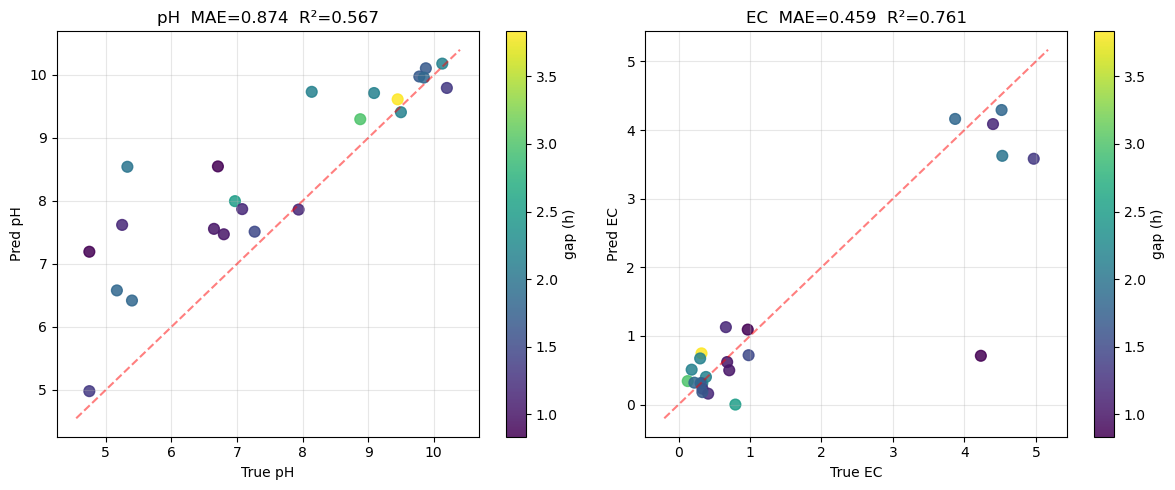

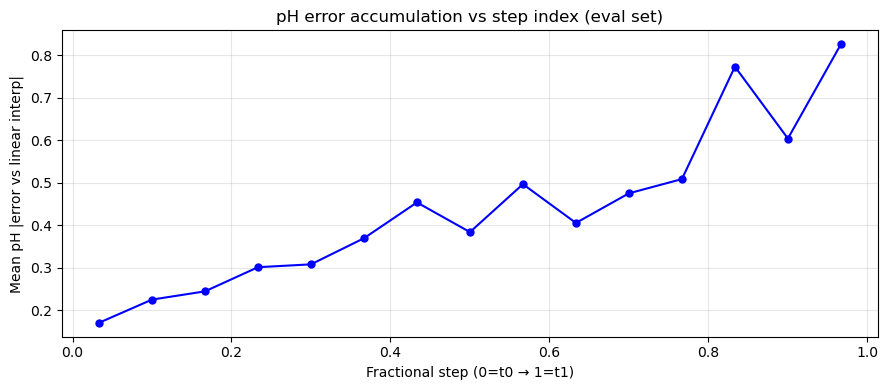

In [9]:
# ==========================================
# 9. Results + Diagnostics
# ==========================================
bins   = [0, 2, 8, np.inf]
labels = ["Short (0-2h)", "Medium (2-8h)", "Long (8h+)"]

ph_df["gap_bin"] = pd.cut(ph_df["gap_h"], bins=bins, labels=labels)
ec_df["gap_bin"] = pd.cut(ec_df["gap_h"], bins=bins, labels=labels)

print("pH gap-bin report:")
print(ph_df.groupby("gap_bin", observed=True).agg(
    n=("ph_ae","count"),
    ph_mae=("ph_ae","mean"),
    ph_naive=("ph_ae_naive","mean"),
).round(4).to_string())

print("\nEC gap-bin report:")
print(ec_df.groupby("gap_bin", observed=True).agg(
    n=("ec_ae","count"),
    ec_mae=("ec_ae","mean"),
    ec_naive=("ec_ae_naive","mean"),
).round(4).to_string())

# Summary table
print("\n" + "="*65)
summary = pd.DataFrame([
    {"Model": "V3 XGBoost",    "pH MAE": 0.4187, "EC MAE": 0.1763,
     "pH R²": 0.850, "EC R²": 0.814, "Notes": "interval features, all gaps"},
    {"Model": "LSTM V6 (this)","pH MAE": round(ph_mae,4), "EC MAE": round(ec_mae,4),
     "pH R²": round(ph_r2,3),  "EC R²": round(ec_r2,3),
     "Notes": f"≤{MAX_GAP_H}h, 10-min steps, separate models"},
])
print(summary.to_string(index=False))

# ── Scatter plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, pred_c, true_c, naive_c, mae, r2, name, color in [
    (axes[0], ph_df, "ph_pred", "ph_true", "ph_naive",
     ph_mae, ph_r2, "pH", "steelblue"),
    (axes[1], ec_df, "ec_pred", "ec_true", "ec_naive",
     ec_mae, ec_r2, "EC", "seagreen"),
]:
    lo = min(df[true_c].min(), df[pred_c].min()) - 0.2
    hi = max(df[true_c].max(), df[pred_c].max()) + 0.2
    sc = ax.scatter(df[true_c], df[pred_c], c=df["gap_h"],
                    cmap="viridis", s=60, alpha=0.85)
    ax.plot([lo, hi], [lo, hi], "r--", alpha=0.5)
    plt.colorbar(sc, ax=ax, label="gap (h)")
    ax.set_xlabel(f"True {name}"); ax.set_ylabel(f"Pred {name}")
    ax.set_title(f"{name}  MAE={mae:.3f}  R²={r2:.3f}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── pH error vs step index ────────────────────────────────────────────────────
step_recs = []
for _, row in ph_df.iterrows():
    chain = row["_ph_chain"]
    K = len(chain)
    if K == 0: continue
    ph0_i, ph1_i = row["ph_naive"], row["ph_true"]
    for k, ph_k in enumerate(chain):
        frac   = (k+1)/K
        interp = ph0_i + (ph1_i - ph0_i) * frac
        step_recs.append((frac, abs(ph_k - interp)))

sr = np.array(step_recs)
n_bins = 15
bedges = np.linspace(0, 1, n_bins+1)
bidx   = np.clip(np.digitize(sr[:,0], bedges)-1, 0, n_bins-1)
bmid   = (bedges[:-1]+bedges[1:])/2
bmean  = [sr[bidx==b,1].mean() if (bidx==b).any() else np.nan for b in range(n_bins)]

fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.plot(bmid, bmean, "b-o", ms=5)
ax2.set_xlabel("Fractional step (0=t0 → 1=t1)")
ax2.set_ylabel("Mean pH |error vs linear interp|")
ax2.set_title("pH error accumulation vs step index (eval set)")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
